# ANÁLISES - TESTES DE HIPÓTESES

Referência principal: Inferência Estatística - Casella & Berger. 


Considere-se o teste de hipóteses:

$$
H_{0}: \boldsymbol{\theta}=\boldsymbol{\theta}_{0} \\
H_{1}: \boldsymbol{\theta} \neq \boldsymbol{\theta}_{0}
$$

Seja $\Phi_{\boldsymbol{\theta}}$ o espaço-parâmetro associado a $\boldsymbol{\theta}$, e $\Phi_{\boldsymbol{\theta}_{0}} = \{ \boldsymbol{\theta}_{0} \}$. Considerando um conjunto de observações $\textbf{X}$, o teste de razão de verossimilhança (Likelihood Ratio Test - LRT) possui a estatística de teste:

$$\lambda(\textbf{X}) = \frac{\max_{\Phi_{\boldsymbol{\theta}_{0}}} L_{\textbf{X}}(\boldsymbol{\theta})}{\max_{\Phi_{\boldsymbol{\theta}}} L_{\textbf{X}}(\boldsymbol{\theta})} $$

Define-se a região de rejeição do LRT como:

$$
R = \{ \textbf{X}: \lambda(\textbf{X}) <=c \}
$$

Sejam $C_{ref}$ e $C_{alt}$ casos de teste "referência" e "alternativo". Deseja-se testar a hipótese nula de os erros de estimativas $\delta_{alt}({\widehat{\textbf{B}}})$ de $C_{alt}$ serem distribuídos de acordo com os mesmos parâmetros dos erros $\delta_{ref}({\widehat{\textbf{B}}})$ relativos a $C_{ref}$. As estimativas $\widehat{\textbf{B}}$ podem ser MAP ou MMSE. Supondo que $\delta_{ref}({\widehat{\textbf{B}}})$ possui distribuição governada por paràmetros $\boldsymbol{\theta}_{ref}$, e que $\delta_{alt}({\widehat{\textbf{B}}})$ possui distribuição governada pelo conjunto de parâmetros $\boldsymbol{\theta}_{alt}$, define-se o teste de hipóteses

$$
H_{0}: \boldsymbol{\theta}_{alt}=\boldsymbol{\theta}_{ref} \\
H_{1}: \boldsymbol{\theta}_{alt} \neq \boldsymbol{\theta}_{ref}
$$

Neste ensaio, considera-se como modelo

$$
\delta_{ref}({\widehat{\textbf{B}}}) \sim Gamma(\alpha_{ref}, \beta_{ref}), \; \textrm{e} \\
\delta_{alt}({\widehat{\textbf{B}}}) \sim Gamma(\alpha_{alt}, \beta_{alt}),
$$

em que $Gamma(\alpha, \beta)$ é a distribuição Gama, com densidade de probabilidade

$$
    f(x) = \frac{x^{\alpha-1} \cdot e^{-\beta x} \cdot \beta^{\alpha}}{\Gamma(\alpha)},
$$

em que, por sua vez, $\Gamma(\alpha)$ é a função Gama. Assim, $\boldsymbol{\theta}_{ref}=[\alpha_{ref}, \beta_{ref}]$, e $\boldsymbol{\theta}_{alt}=[\alpha_{alt}, \beta_{alt}]$. Sendo $\Delta_{alt}$ o conjunto de observações de $\delta_{alt}({\widehat{\textbf{B}}})$ para um tipo de estimativa (MAP/MMSE), define-se o LRT

$$ \lambda(\Delta_{alt}) = \frac{L_{\Delta_{alt}}(\alpha_{ref}, \beta_{ref})}{\max_{\alpha, \beta} L_{\Delta_{alt}}(\alpha, \beta)} = \frac{L_{\Delta_{alt}}(\alpha_{ref}, \beta_{ref})}{L_{\Delta_{alt}}(\alpha_{alt}, \beta_{alt})} $$


In [1]:
import os
from pathlib import Path
from pathos.pools import ProcessPool


import pandas as pd
import numpy as np
from scipy import stats as st
from sklearn.feature_selection import mutual_info_regression as MI
from sklearn.mixture import GaussianMixture
from functools import partial

import json
import plotly.graph_objects as go
from matplotlib import pyplot as plt
import seaborn as sns

import sys
sys.path.append('/Users/leonardo.tessarolo/git/bayesian_bss/')
from src import HypothesisTestsCases, ExperimentParser 

# 1. Read and parse raw results

In [2]:
# Experiment name
EXPERIMENT_NAME = 'test_complete_refit_contours_v2'

# Whether or not to save graphs
SAVE_GRAPHS=True

# Whether or not to create folder structure for saving results
CREATE_FOLDER_STRUCTURE = True

# Folder which will contain output directory tree
OUTPUT_DIR='./output'
base_output_path=Path(OUTPUT_DIR)

# Directory which holds experiments
experiment_dir = base_output_path / EXPERIMENT_NAME

# Instantiate and execute parser object
parser = ExperimentParser(experiment_dir)
parser.parse(verbose=True)


####################################################################################################
Total of 100 realizations with executed results
----------------------------------------------------------------------------------------------------
Total of 0 realizations without executed results
####################################################################################################


In [3]:
############################################
# Create folder structure, if so specified #
############################################

# General directory for analysis
analysis_dir = experiment_dir / 'hypothesis_tests'

# Subdirectories
posterior_contour_dir = analysis_dir / 'posterior_contour'
mmse_dir = analysis_dir / 'mmse'
map_dir = analysis_dir / 'map'

if CREATE_FOLDER_STRUCTURE:

    # Create analysis dir, if it doesn't yet exist
    if not analysis_dir.is_dir():
        analysis_dir.mkdir()

    # Create posterior contour dir, if it doesn't yet exist
    if not posterior_contour_dir.is_dir():
        posterior_contour_dir.mkdir()

    # Create mmse dir, if it doesn't yet exist
    if not mmse_dir.is_dir():
        mmse_dir.mkdir()

    # Create map dir, if it doesn't yet exist
    if not map_dir.is_dir():
        map_dir.mkdir()

# 2. Hypothesis Tests

In [6]:
# Define objeto do LRT
lrt = HypothesisTestsCases(
    parser=parser,
    model_type='gmm'
)

## 2.1. SHAPIRO TESTS

In [7]:
lrt.run_shapiro()
lrt.shapiro_results

,test_case,map_error_shapiro_statistic,map_error_shapiro_pvalue,mmse_error_shapiro_statistic,mmse_error_shapiro_pvalue
0,i,0.966193,0.011390,0.909899,4.259154e-06
1,ii,0.966157,0.011319,0.946035,4.588772e-04
2,iii,0.932345,0.000068,0.955501,1.946373e-03
3,iv,0.985898,0.367897,0.972109,3.212944e-02
4,v,0.928564,0.000041,0.951126,9.848616e-04
5,vi,0.928511,0.000041,0.877803,1.466759e-07
6,vii,0.919398,0.000013,0.989219,6.018533e-01
7,viii,0.992184,0.834410,0.959485,3.695913e-03
8,ix,0.991403,0.776486,0.988318,5.319503e-01
9,x,0.991395,0.775846,0.930748,5.489254e-05


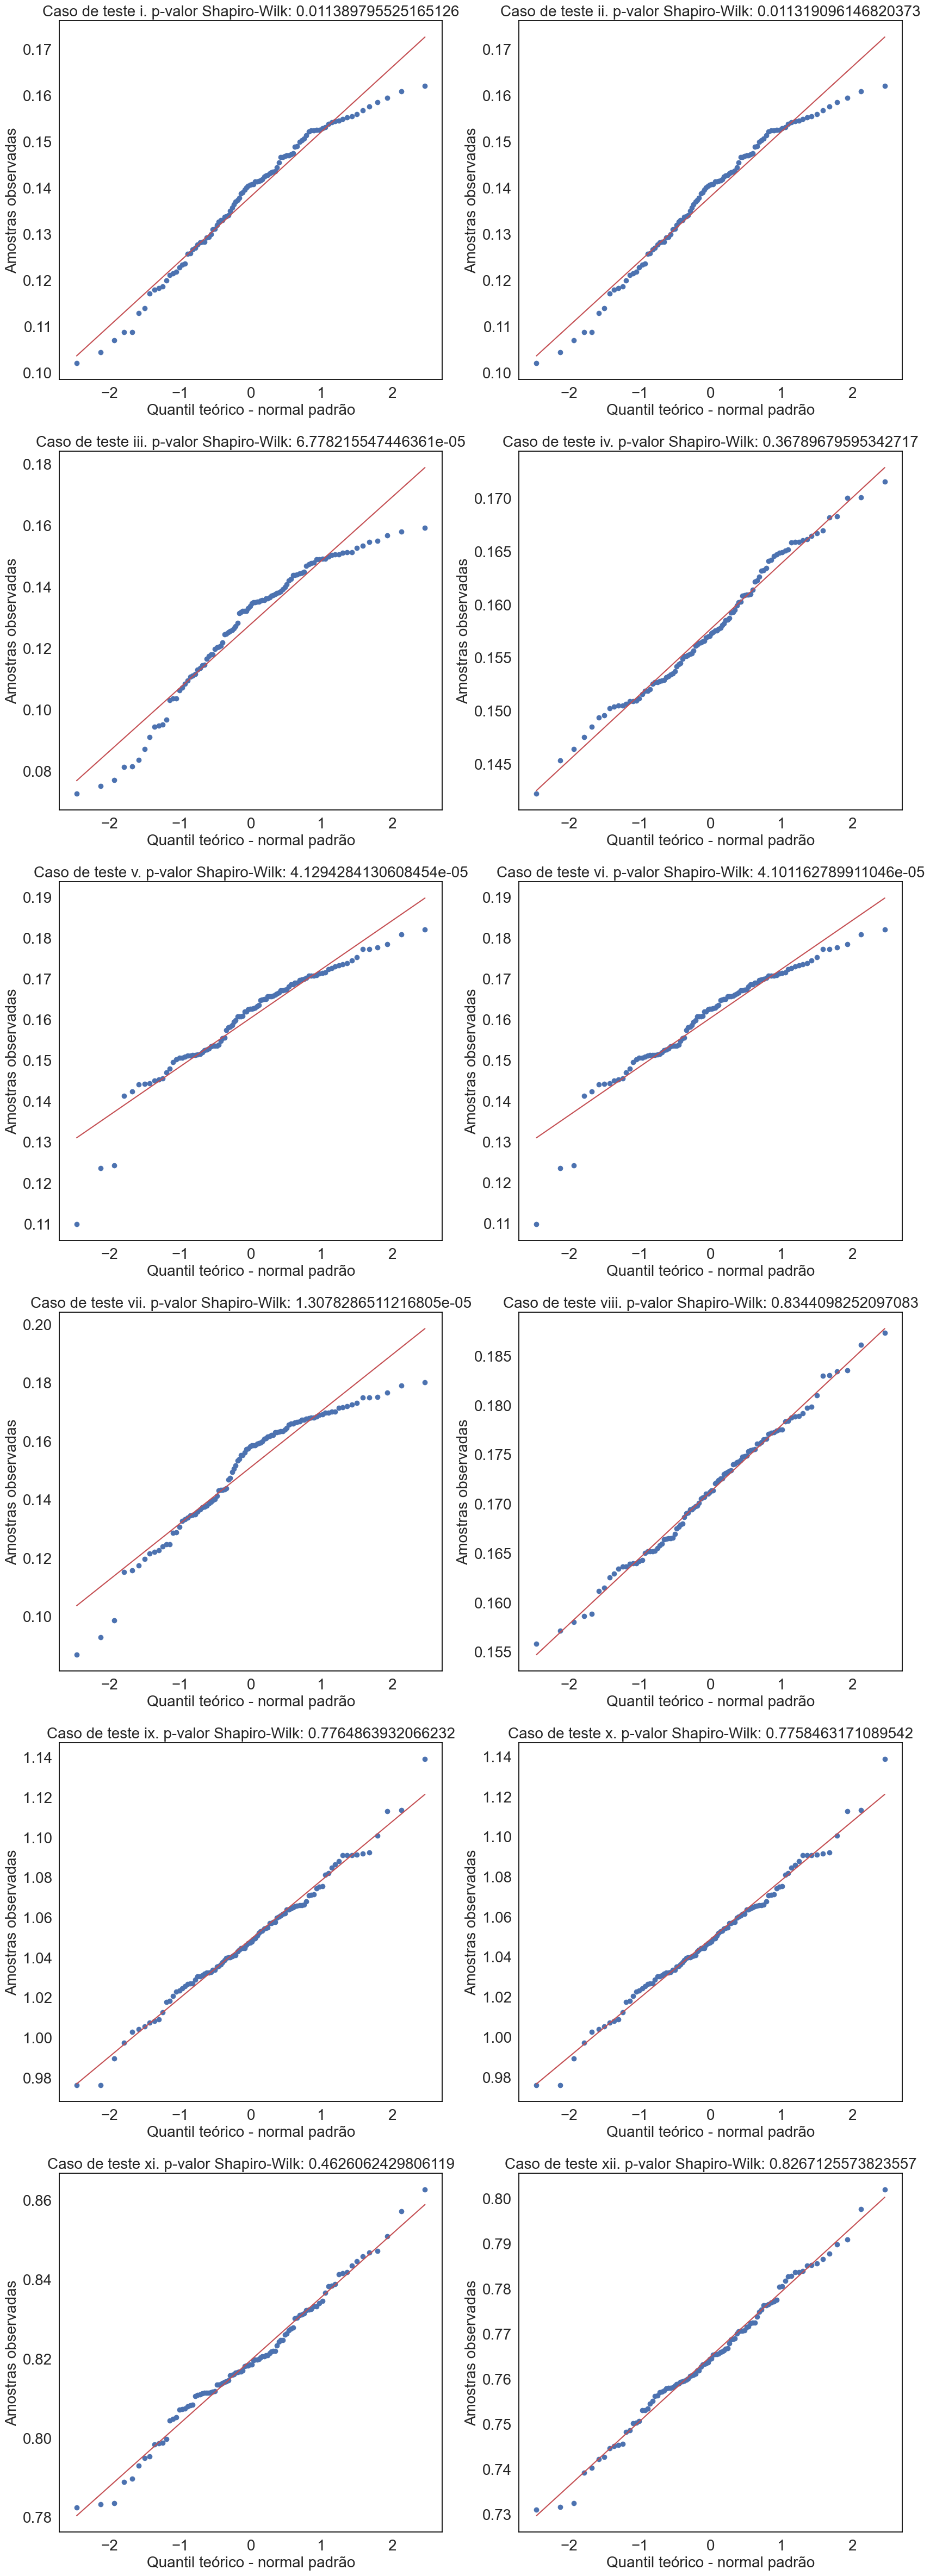

In [8]:
lrt.error_probplot(
    estimate_type='map'
)

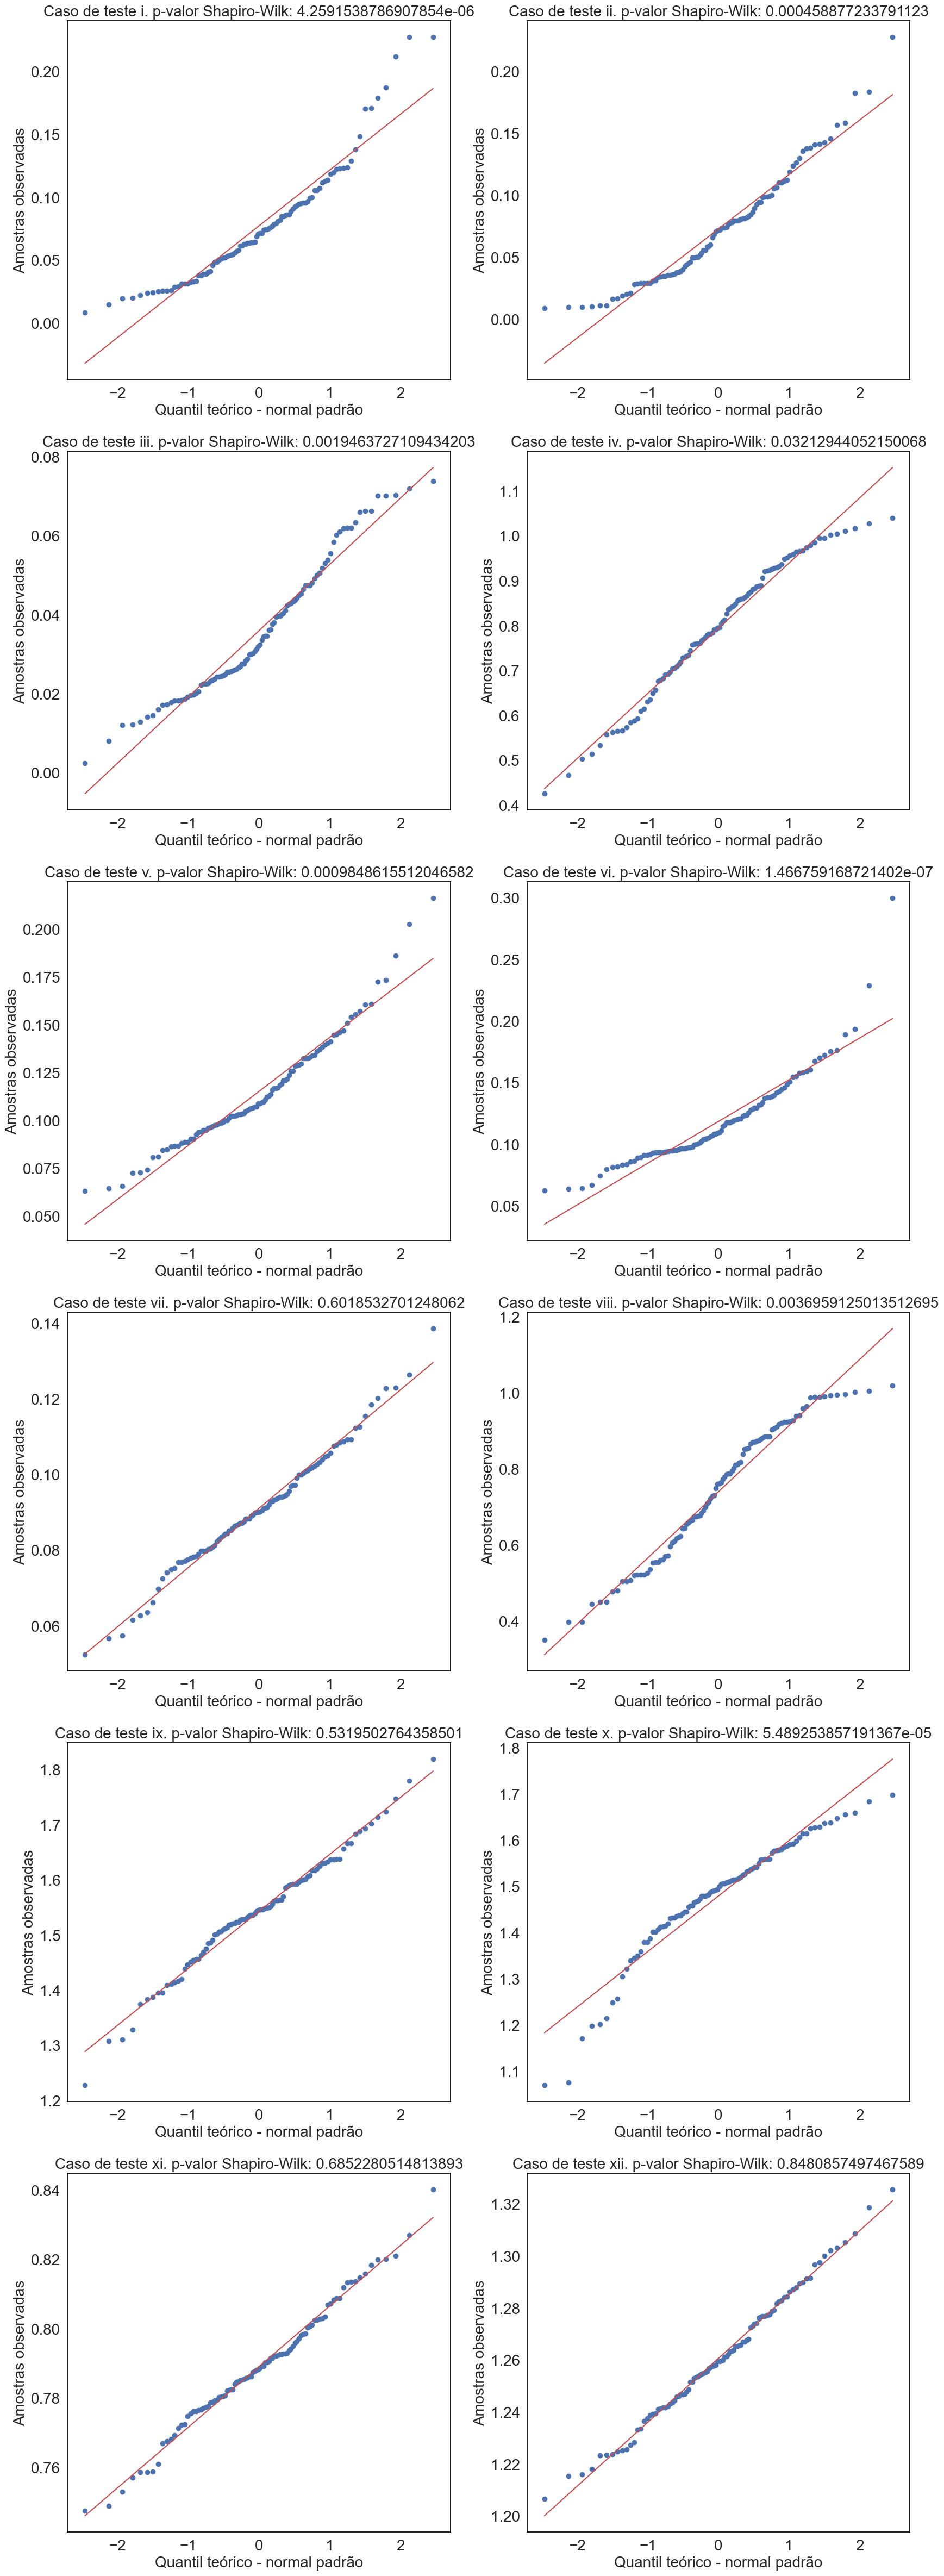

In [9]:
lrt.error_probplot(
    estimate_type='mmse'
)

## 2.2. MAP

{'map': {'i': 1,
  'ii': 1,
  'iii': 2,
  'iv': 1,
  'v': 3,
  'vi': 3,
  'vii': 2,
  'viii': 1,
  'ix': 1,
  'x': 1,
  'xi': 1,
  'xii': 1}}

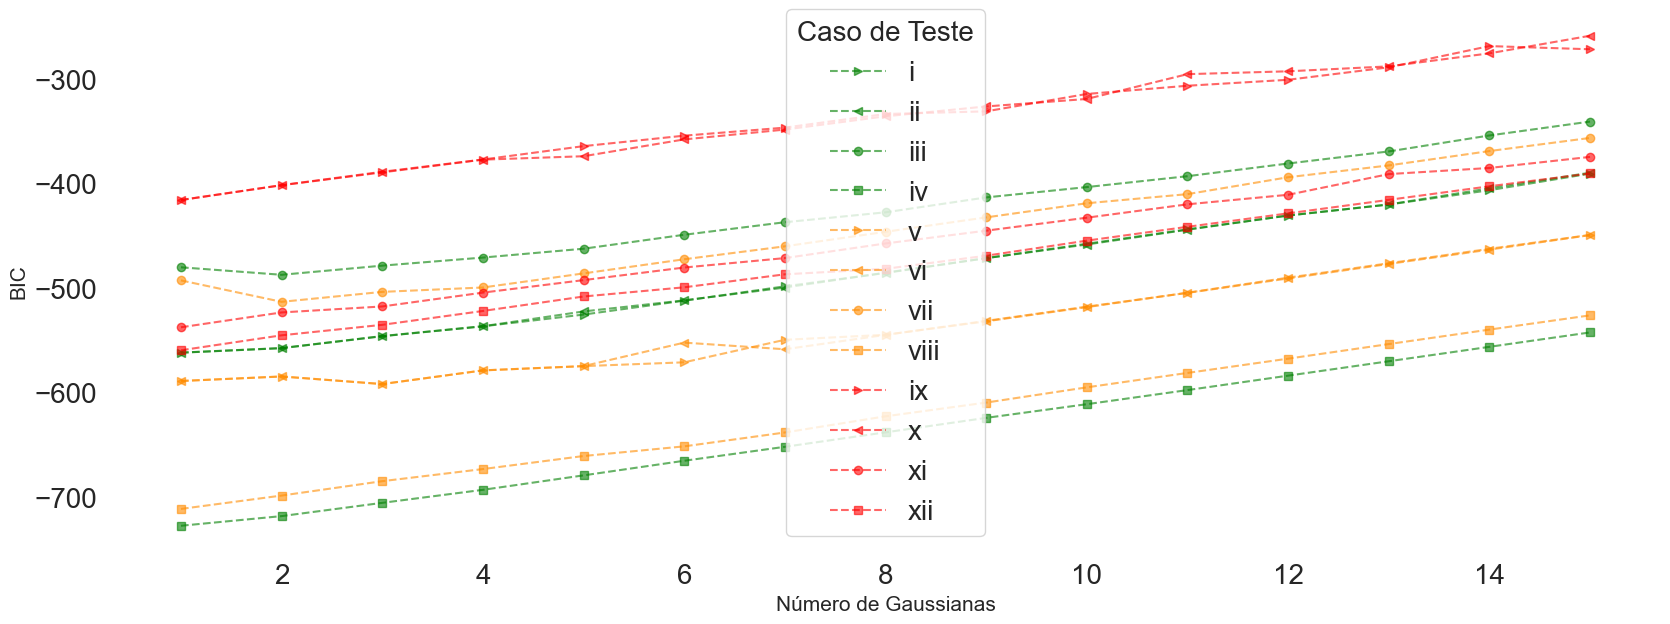

In [10]:
lrt.bic_analysis(
    n_components=range(1,16),
    estimate_type='map',
    save_dir=analysis_dir
)
lrt.best_models

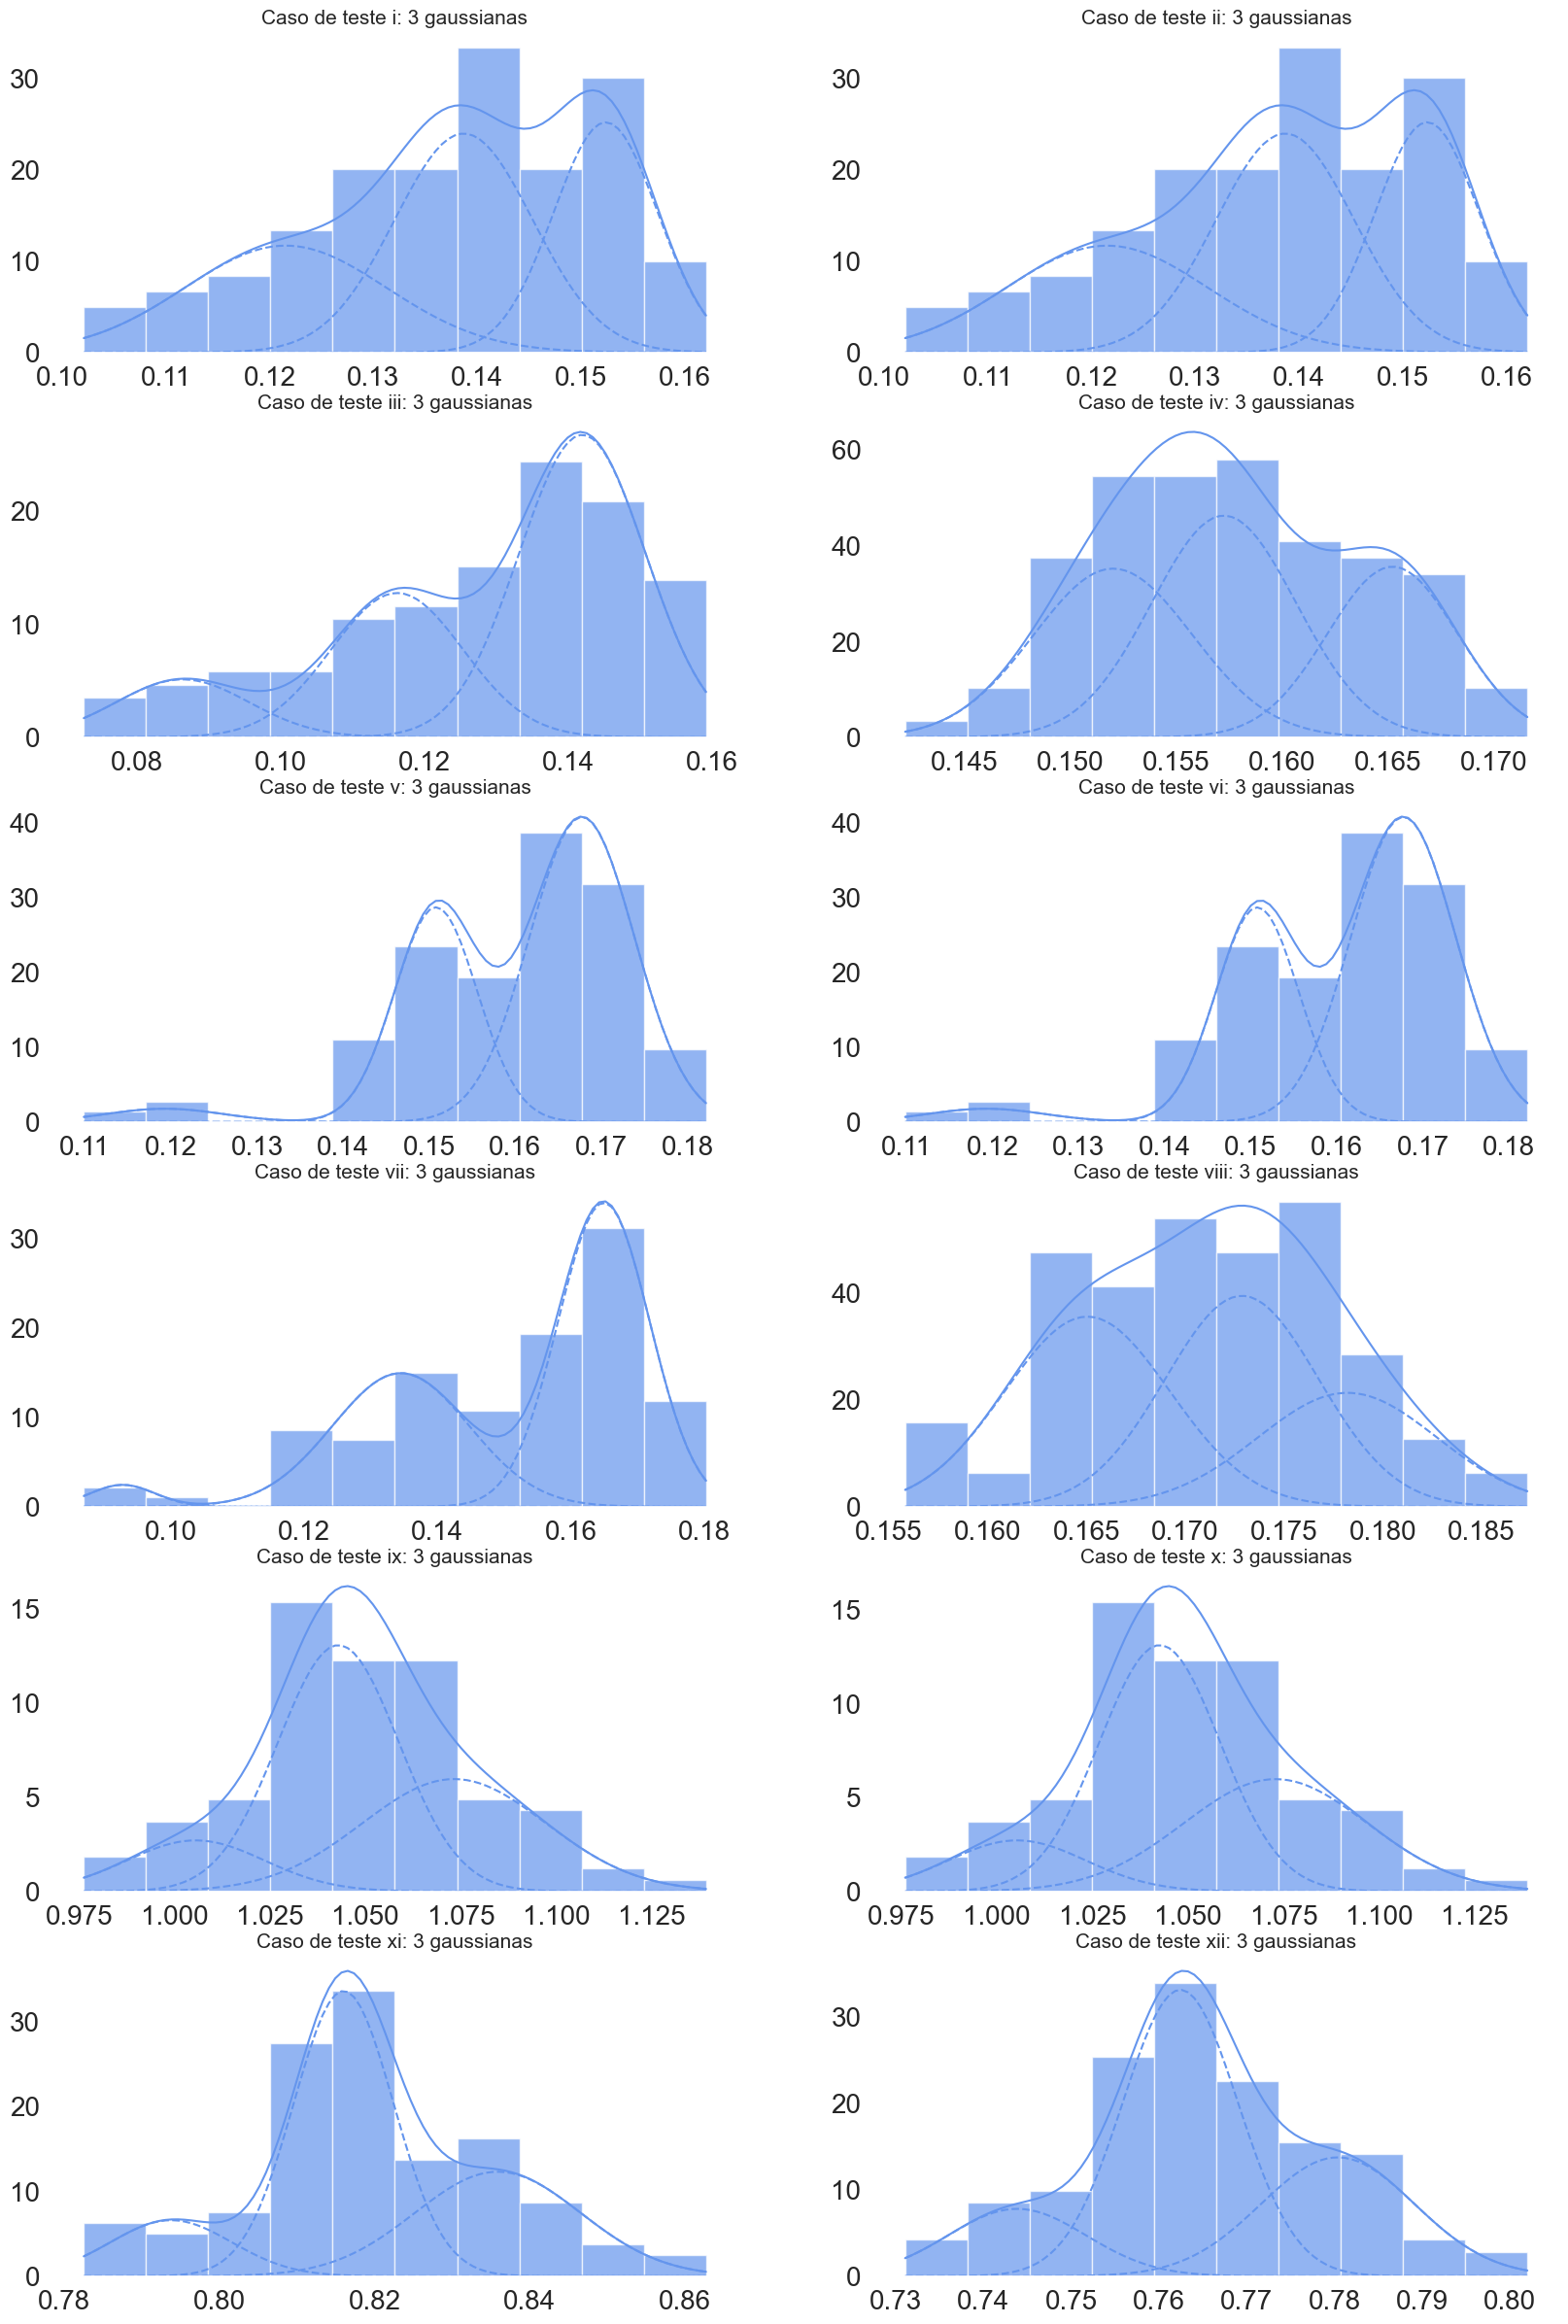

In [11]:
lrt.fit_gmm(
    estimate_type='map',
    n_components=3,
    seeds=range(1000),
    save_dir=analysis_dir
)

In [12]:
#########################
# TESTES - MESMO MODELO #
#########################

lrt.run_compare_cases(
    estimate_type='map',
    means_test='approximate_z_score',
    tests=[
        {
            'ref_case': 'i',
            'alt_cases': ['ii','iii','iv']
        },
        {
            'ref_case': 'v',
            'alt_cases': ['vi','vii','viii']
        },
        {
            'ref_case': 'ix',
            'alt_cases': ['x','xi','xii']
        }
    ]
)

,ref_case,alt_case,ref_case_log_likelihood,alt_case_log_likelihood,lrt_statistic,ref_case_error_mean,alt_case_error_mean,ref_case_error_std,alt_case_error_std,abs_mean_difference,sum_std,mean_diff_wrt_std
0,i,ii,291.462084,291.459108,1.002980e+00,0.138165,0.138135,0.013932,0.013937,0.000030,0.027869,0.010841
1,i,iii,192.818541,257.615329,7.229571e-29,0.138165,0.127861,0.013932,0.020965,0.010304,0.034897,2.952636
2,i,iv,203.489639,371.138269,1.552833e-73,0.138165,0.157698,0.013932,0.006085,0.019533,0.020017,9.758271
3,v,vi,314.434040,314.434870,9.991708e-01,0.160428,0.160406,0.012165,0.012170,0.000022,0.024335,0.008952
4,v,vii,193.412290,272.455446,4.698870e-35,0.160428,0.151155,0.012165,0.019691,0.009273,0.031856,2.910803
5,v,viii,300.202215,360.830710,4.670666e-27,0.160428,0.171245,0.012165,0.006596,0.010817,0.018761,5.765888
6,ix,x,213.016095,213.019678,9.964233e-01,1.049202,1.048892,0.028939,0.028921,0.000310,0.057859,0.053639
7,ix,xi,-5192.205891,277.304382,0.000000e+00,1.049202,0.819674,0.028939,0.015734,0.229528,0.044673,51.380056
8,ix,xii,-8051.259131,286.053710,0.000000e+00,1.049202,0.765002,0.028939,0.014095,0.284200,0.043033,66.042133


In [13]:
########################
# TESTES - MESMA PRIOR #
########################

lrt.run_compare_cases(
    estimate_type='map',
    means_test='approximate_z_score',
    tests=[
        {
            'ref_case': 'i',
            'alt_cases': ['v','ix']
        },
        {
            'ref_case': 'ii',
            'alt_cases': ['vi','x']
        },
        {
            'ref_case': 'iii',
            'alt_cases': ['vii','xi']
        },
        {
            'ref_case': 'iv',
            'alt_cases': ['viii','xii']
        },
        {
            'ref_case': 'v',
            'alt_cases': ['ix']
        },
        {
            'ref_case': 'vi',
            'alt_cases': ['x']
        },
        {
            'ref_case': 'vii',
            'alt_cases': ['xi']
        },
        {
            'ref_case': 'viii',
            'alt_cases': ['xii']
        },
    ]
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/baye

,ref_case,alt_case,ref_case_log_likelihood,alt_case_log_likelihood,lrt_statistic,ref_case_error_mean,alt_case_error_mean,ref_case_error_std,alt_case_error_std,abs_mean_difference,sum_std,mean_diff_wrt_std
0,i,v,-16.812798,314.469365,1.336548e-144,0.138165,0.160428,0.013932,0.012165,0.022262,0.026097,8.530711
1,i,ix,-inf,212.954875,0.000000e+00,0.138165,1.049202,0.013932,0.028939,0.911037,0.042871,212.508668
2,ii,vi,-17.161943,314.434870,9.757401e-145,0.138135,0.160406,0.013937,0.012170,0.022271,0.026107,8.530506
3,ii,x,-inf,213.019678,0.000000e+00,0.138135,1.048892,0.013937,0.028921,0.910756,0.042858,212.504847
4,iii,vii,90.758072,272.455446,1.229795e-79,0.127861,0.151155,0.020965,0.019691,0.023293,0.040657,5.729314
5,iii,xi,-inf,277.304382,0.000000e+00,0.127861,0.819674,0.020965,0.015734,0.691812,0.036699,188.508919
6,iv,viii,-43.138055,360.830710,3.619046e-176,0.157698,0.171245,0.006085,0.006596,0.013546,0.012681,10.682561
7,iv,xii,-inf,286.053710,0.000000e+00,0.157698,0.765002,0.006085,0.014095,0.607303,0.020179,300.950749
8,v,ix,-inf,212.954875,0.000000e+00,0.160428,1.049202,0.012165,0.028939,0.888774,0.041103,216.229371
9,vi,x,-inf,213.019678,0.000000e+00,0.160406,1.048892,0.012170,0.028921,0.888486,0.041091,216.225714


## 2.3. MMSE

{'i': 2,
 'ii': 1,
 'iii': 2,
 'iv': 1,
 'v': 1,
 'vi': 2,
 'vii': 1,
 'viii': 2,
 'ix': 1,
 'x': 2,
 'xi': 1,
 'xii': 1}

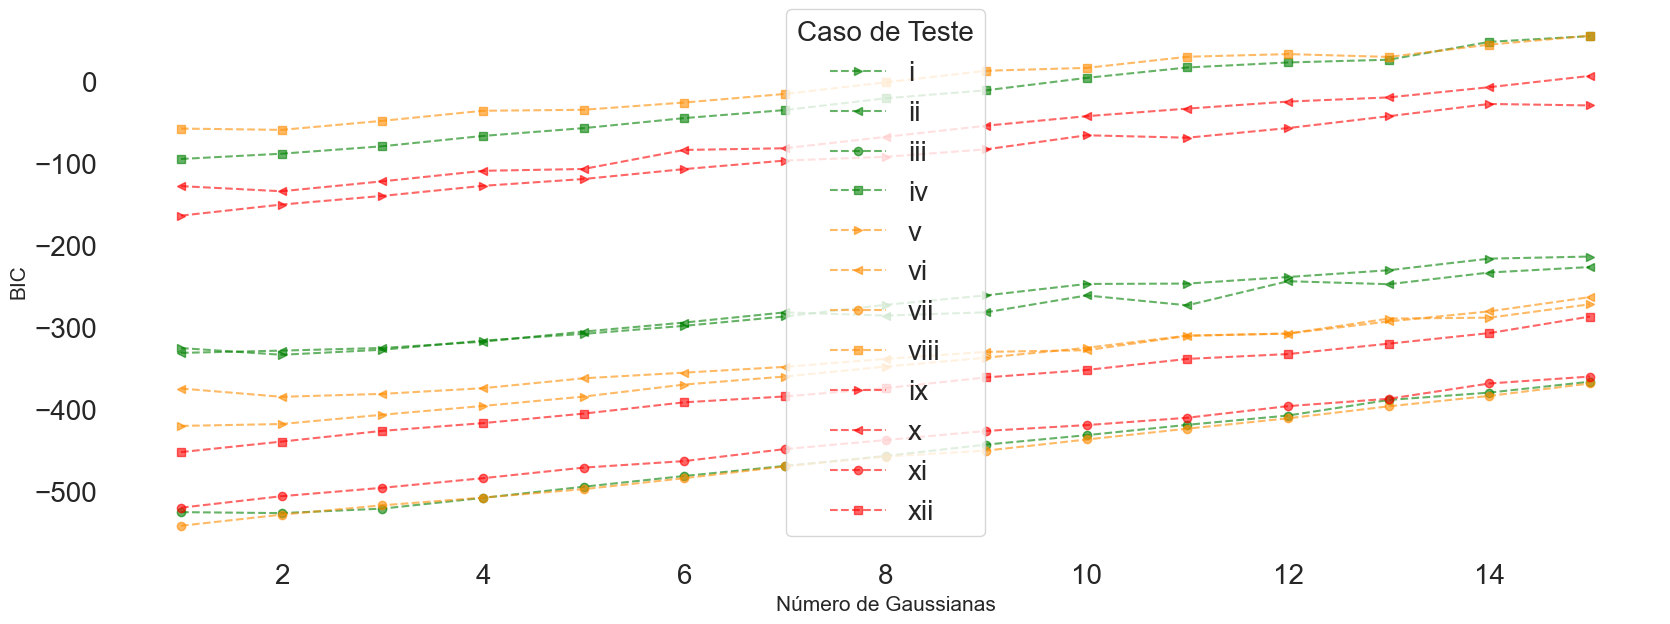

In [14]:
lrt.bic_analysis(
    n_components=range(1,16),
    estimate_type='mmse',
    save_dir=analysis_dir
)
lrt.best_models['mmse']

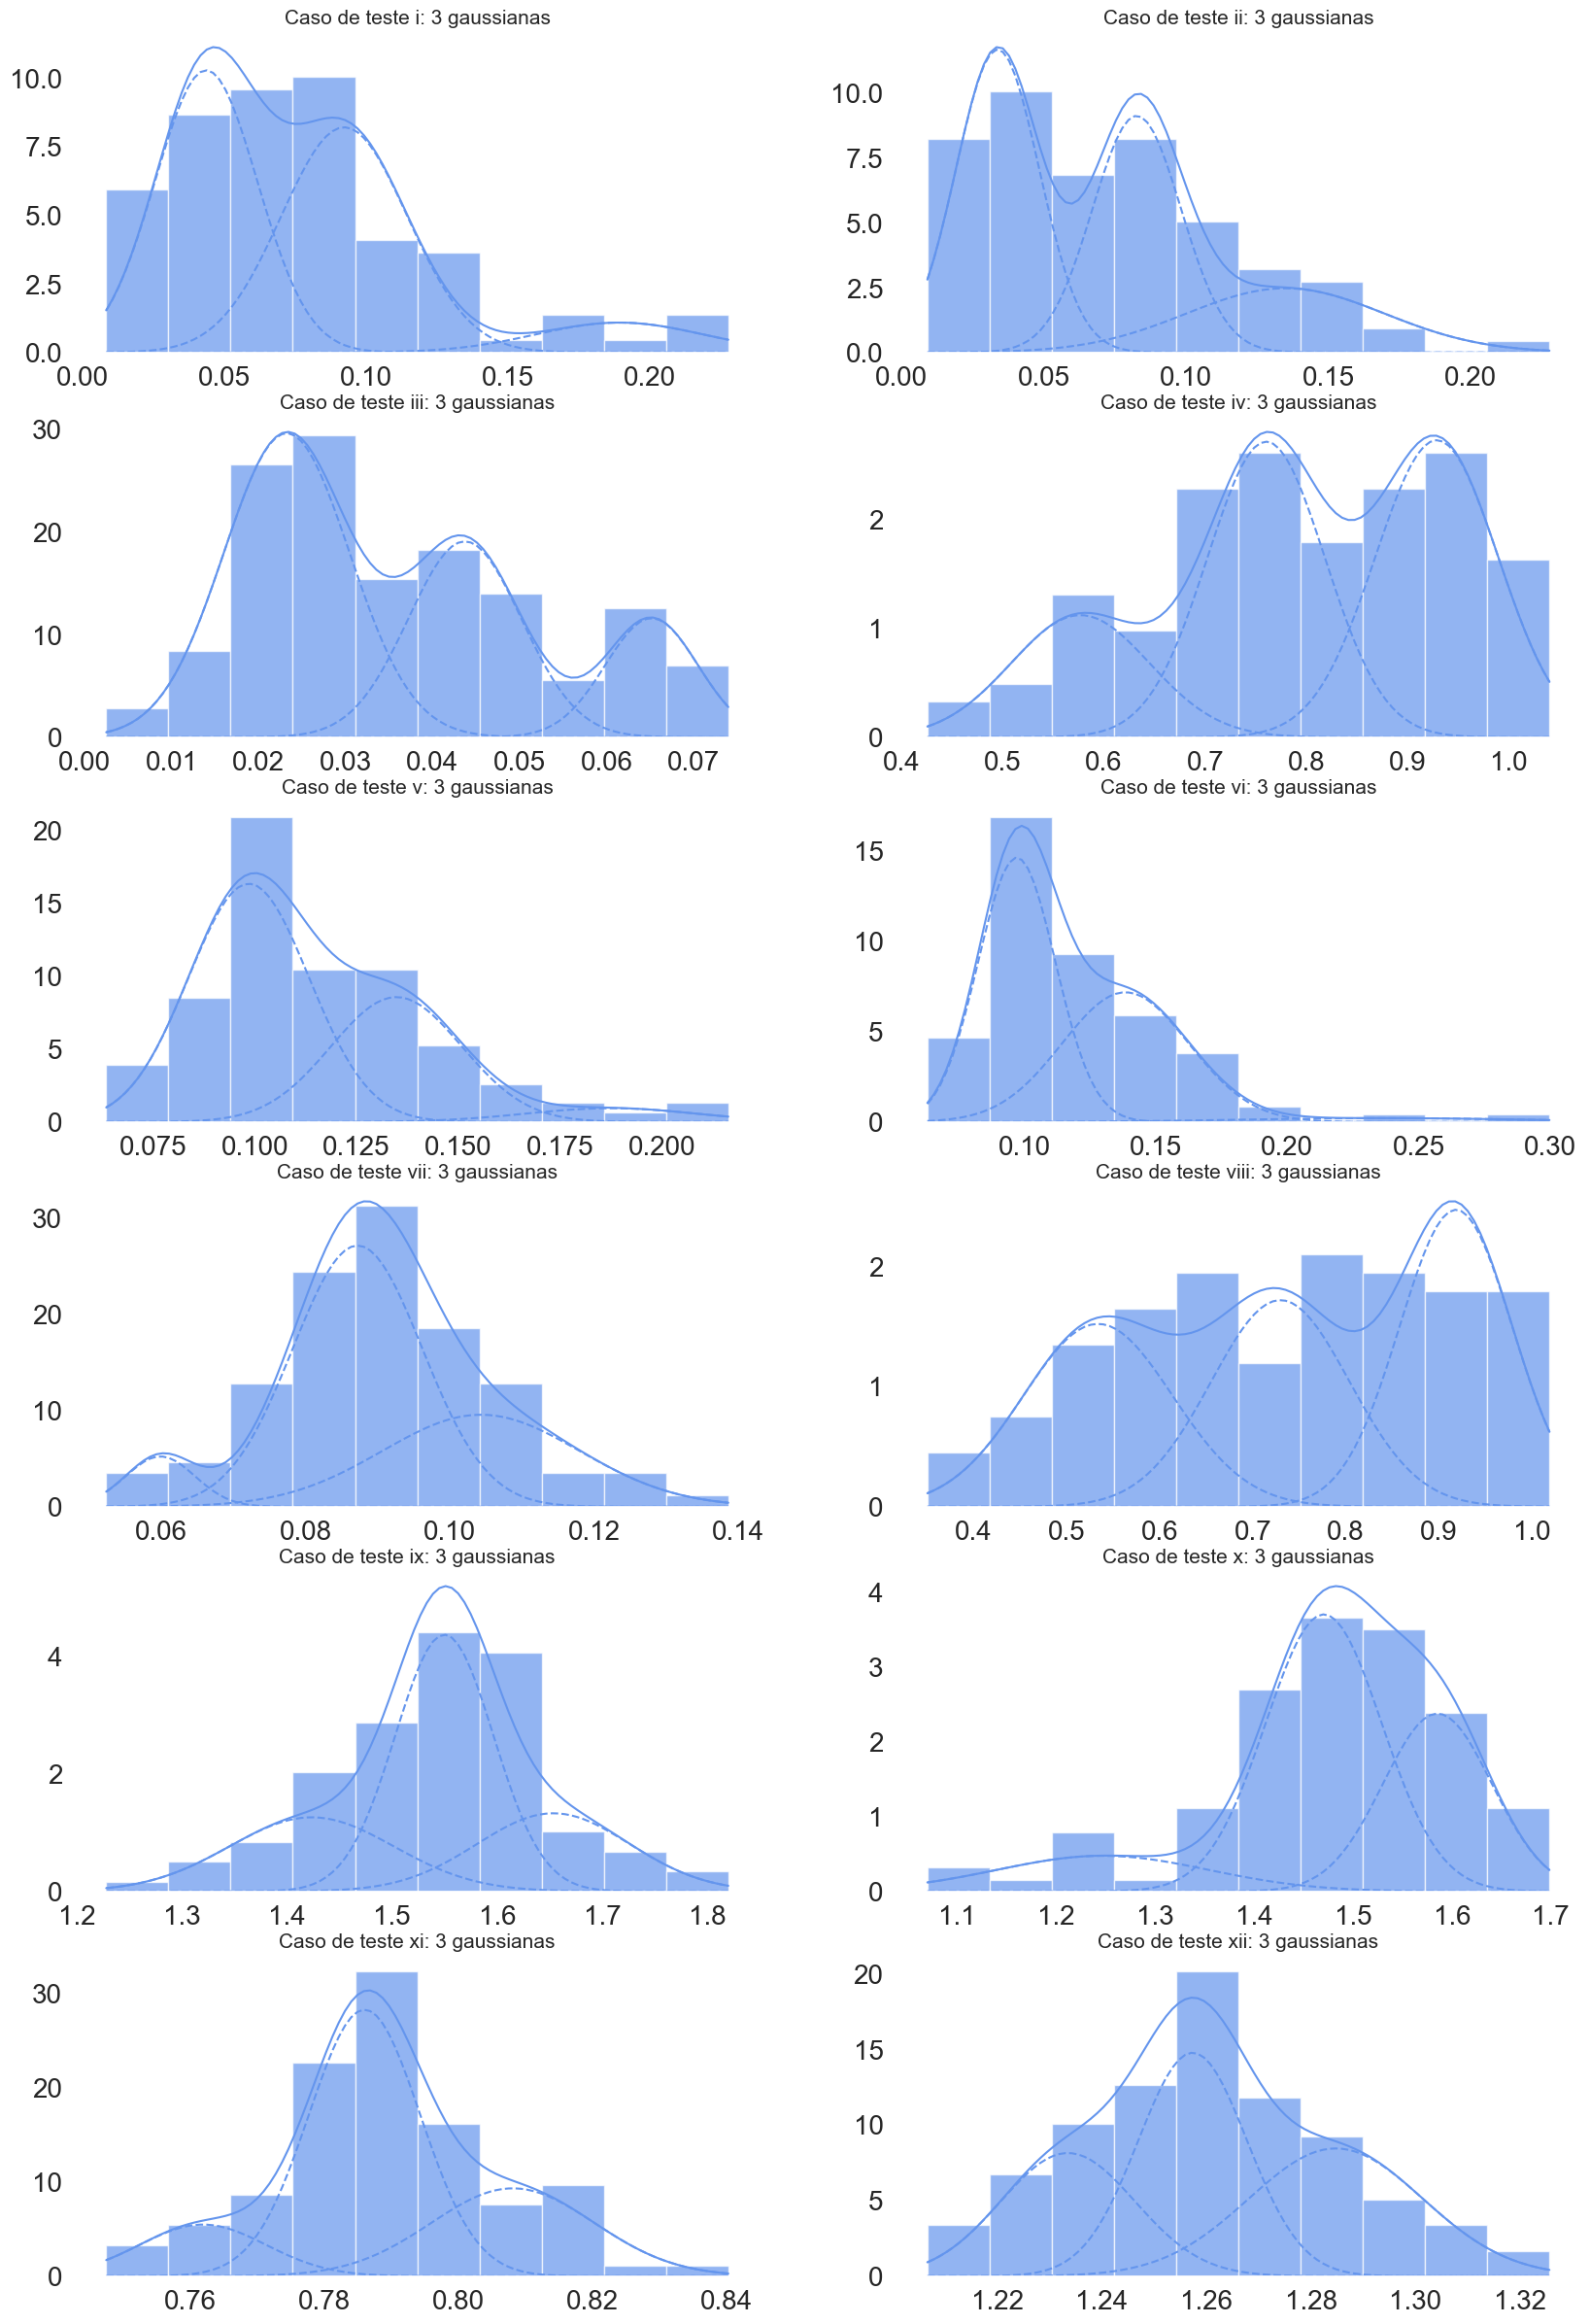

In [15]:
lrt.fit_gmm(
    estimate_type='mmse',
    n_components=3,
    seeds=range(1000),
    save_dir=analysis_dir
)

In [16]:
#########################
# TESTES - MESMO MODELO #
#########################

lrt.run_compare_cases(
    estimate_type='mmse',
    means_test='approximate_z_score',
    tests=[
        {
            'ref_case': 'i',
            'alt_cases': ['ii','iii','iv']
        },
        {
            'ref_case': 'v',
            'alt_cases': ['vi','vii','viii']
        },
        {
            'ref_case': 'ix',
            'alt_cases': ['x','xi','xii']
        }
    ]
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods


,ref_case,alt_case,ref_case_log_likelihood,alt_case_log_likelihood,lrt_statistic,ref_case_error_mean,alt_case_error_mean,ref_case_error_std,alt_case_error_std,abs_mean_difference,sum_std,mean_diff_wrt_std
0,i,ii,1.719676e+02,180.768220,1.506420e-04,0.077529,0.073072,0.045551,0.044234,0.004457,0.089785,0.496453
1,i,iii,1.936479e+02,278.713097,1.139311e-37,0.077529,0.036051,0.045551,0.016767,0.041478,0.062319,6.655829
2,i,iv,-2.241887e+04,57.909806,0.000000e+00,0.077529,0.794753,0.045551,0.144096,0.717224,0.189647,37.818807
3,v,vi,1.960246e+02,209.038753,2.228653e-06,0.115409,0.118775,0.028349,0.035604,0.003366,0.063953,0.526348
4,v,vii,2.236110e+02,278.387466,1.625131e-24,0.115409,0.091098,0.028349,0.015433,0.024311,0.043782,5.552696
5,v,viii,-inf,42.551343,0.000000e+00,0.115409,0.740500,0.028349,0.173411,0.625091,0.201760,30.981891
6,ix,x,4.279342e+01,79.344999,1.336131e-16,1.543501,1.479663,0.102045,0.122128,0.063838,0.224172,2.847715
7,ix,xi,-3.257029e+03,266.795989,0.000000e+00,1.543501,0.789132,0.102045,0.017227,0.754369,0.119271,63.248119
8,ix,xii,-1.972895e+02,231.253047,7.697431e-187,1.543501,1.260740,0.102045,0.024170,0.282761,0.126214,22.403218


In [17]:
########################
# TESTES - MESMA PRIOR #
########################

lrt.run_compare_cases(
    estimate_type='map',
    means_test='approximate_z_score',
    tests=[
        {
            'ref_case': 'i',
            'alt_cases': ['v','ix']
        },
        {
            'ref_case': 'ii',
            'alt_cases': ['vi','x']
        },
        {
            'ref_case': 'iii',
            'alt_cases': ['vii','xi']
        },
        {
            'ref_case': 'iv',
            'alt_cases': ['viii','xii']
        },
        {
            'ref_case': 'v',
            'alt_cases': ['ix']
        },
        {
            'ref_case': 'vi',
            'alt_cases': ['x']
        },
        {
            'ref_case': 'vii',
            'alt_cases': ['xi']
        },
        {
            'ref_case': 'viii',
            'alt_cases': ['xii']
        },
    ]
)

/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/baye

,ref_case,alt_case,ref_case_log_likelihood,alt_case_log_likelihood,lrt_statistic,ref_case_error_mean,alt_case_error_mean,ref_case_error_std,alt_case_error_std,abs_mean_difference,sum_std,mean_diff_wrt_std
0,i,v,-16.812798,314.469365,1.336548e-144,0.138165,0.160428,0.013932,0.012165,0.022262,0.026097,8.530711
1,i,ix,-inf,212.954875,0.000000e+00,0.138165,1.049202,0.013932,0.028939,0.911037,0.042871,212.508668
2,ii,vi,-17.161943,314.434870,9.757401e-145,0.138135,0.160406,0.013937,0.012170,0.022271,0.026107,8.530506
3,ii,x,-inf,213.019678,0.000000e+00,0.138135,1.048892,0.013937,0.028921,0.910756,0.042858,212.504847
4,iii,vii,90.758072,272.455446,1.229795e-79,0.127861,0.151155,0.020965,0.019691,0.023293,0.040657,5.729314
5,iii,xi,-inf,277.304382,0.000000e+00,0.127861,0.819674,0.020965,0.015734,0.691812,0.036699,188.508919
6,iv,viii,-43.138055,360.830710,3.619046e-176,0.157698,0.171245,0.006085,0.006596,0.013546,0.012681,10.682561
7,iv,xii,-inf,286.053710,0.000000e+00,0.157698,0.765002,0.006085,0.014095,0.607303,0.020179,300.950749
8,v,ix,-inf,212.954875,0.000000e+00,0.160428,1.049202,0.012165,0.028939,0.888774,0.041103,216.229371
9,vi,x,-inf,213.019678,0.000000e+00,0.160406,1.048892,0.012170,0.028921,0.888486,0.041091,216.225714


## 2.4 MAP vs MMSE

/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods
/Users/leonardo.tessarolo/git/bayesian_bss/src/hypothesis_tests.py:244: RuntimeWarning: divide by zero encountered in log
  np.log(y) for y in model_likelihoods


,case,map_log_likelihood,mmse_log_likelihood,lrt_statistic,map_error_mean,mmse_error_mean,difference_mean,difference_std,shapiro_statistic,shapiro_pvalue,t_test_statistic,t_test_pvalue
0,i,-1.857053e+03,181.844345,0.000000e+00,0.138165,0.077529,0.060636,0.048912,0.914801,7.536314e-06,12.397069,3.658491e-22
1,ii,-1.995227e+03,180.768220,0.000000e+00,0.138135,0.073072,0.065064,0.044963,0.954330,1.618231e-03,14.470339,1.809198e-26
2,iii,-1.487957e+03,278.713097,0.000000e+00,0.127861,0.036051,0.091811,0.027173,0.923736,2.233888e-05,33.787500,1.857532e-56
3,iv,-inf,57.909806,0.000000e+00,0.157698,0.794753,-0.637054,0.148515,0.974204,4.675690e-02,-42.895018,4.593867e-66
4,v,-4.096587e+02,221.824714,5.626225e-275,0.160428,0.115409,0.045019,0.028146,0.876978,1.354863e-07,15.994567,1.696484e-29
5,vi,-6.512636e+02,209.038753,0.000000e+00,0.160406,0.118775,0.041631,0.034925,0.852255,1.437936e-08,11.920132,3.801626e-21
6,vii,-2.136547e+02,278.387466,2.036104e-214,0.151155,0.091098,0.060057,0.019887,0.923037,2.047091e-05,30.198653,4.715725e-52
7,viii,-inf,42.551343,0.000000e+00,0.171245,0.740500,-0.569255,0.177248,0.961034,4.768689e-03,-32.116223,1.859737e-54
8,ix,-1.985102e+04,88.156991,0.000000e+00,1.049202,1.543501,-0.494299,0.104075,0.985743,3.587859e-01,-47.494512,3.047917e-70
9,x,-1.543515e+04,79.344999,0.000000e+00,1.048892,1.479663,-0.430771,0.120761,0.923359,2.131185e-05,-35.671493,1.292349e-58


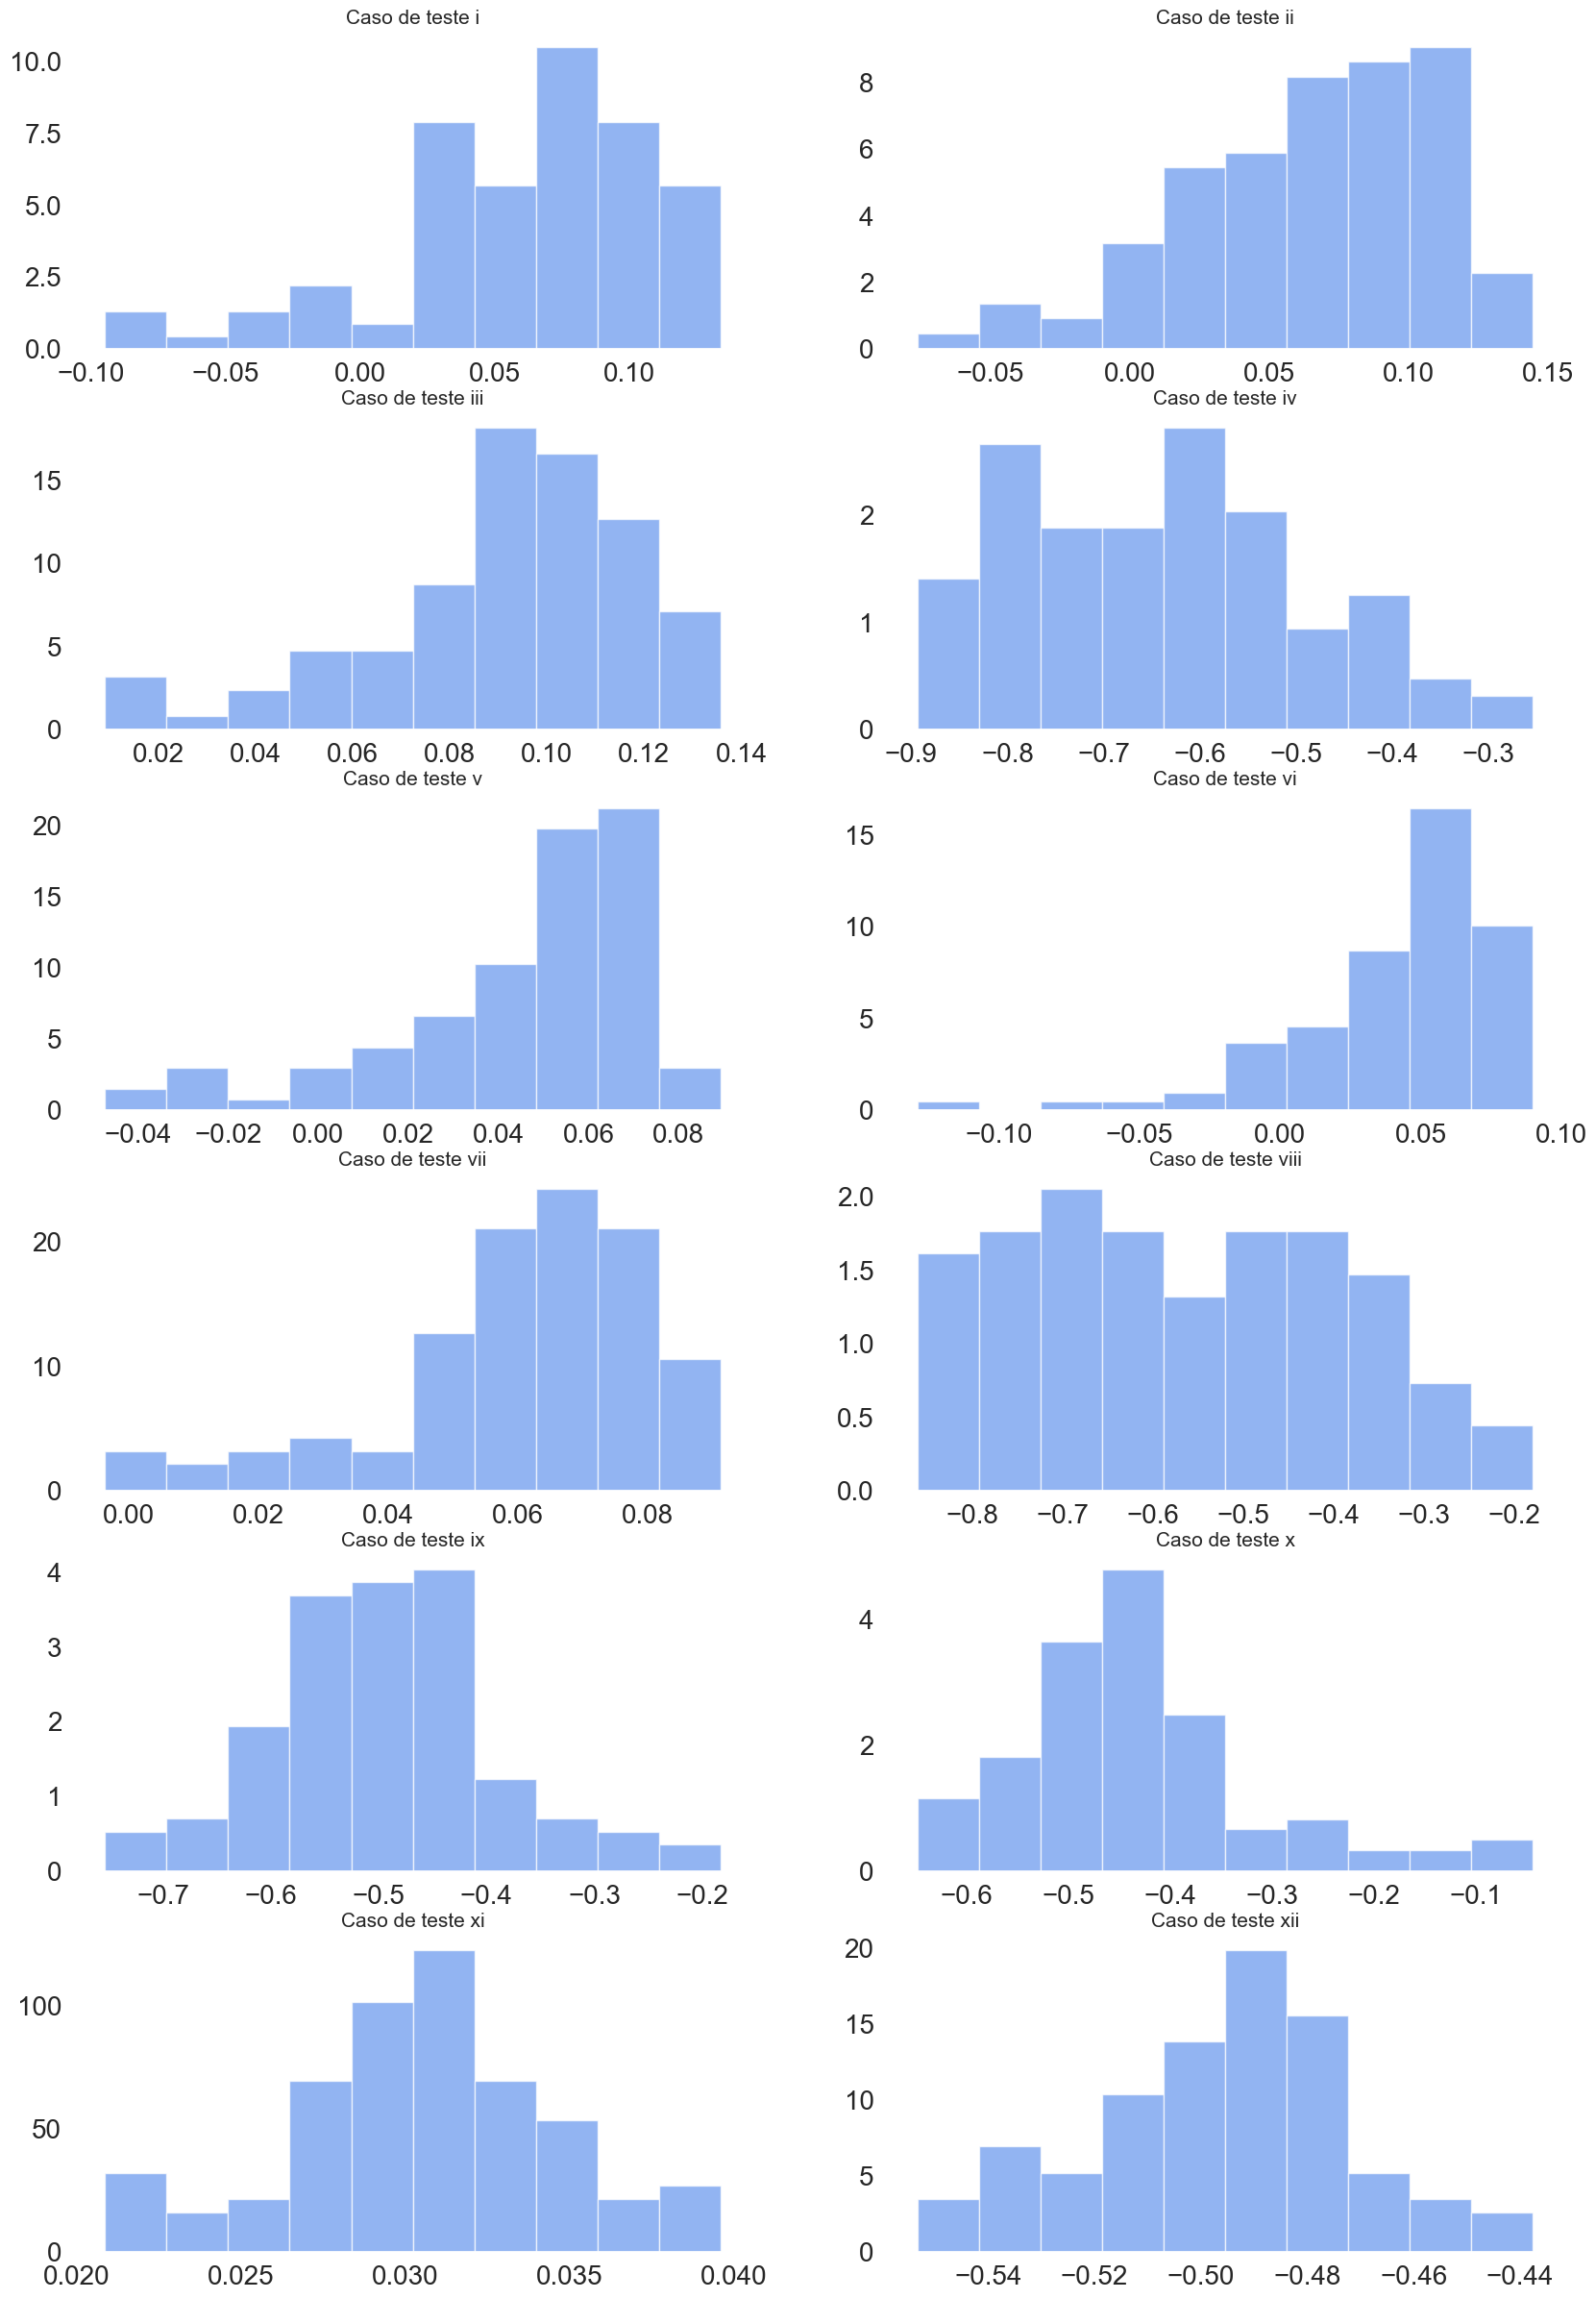

In [18]:
lrt.run_compare_map_mmse(
    means_test='paired_t_test',
    save_dir=analysis_dir
)

,estimate_type,test_case,b11_mean,b12_mean,b21_mean,b22_mean,error_mean,b11_std,b12_std,b21_std,b22_std,error_std
0,MAP,i,0.560608,-0.839997,0.423562,1.105064,0.138165,0.020746,0.025173,0.022003,0.022939,0.014002
1,MAP,ii,0.560595,-0.840035,0.423580,1.105044,0.138135,0.020747,0.025179,0.022005,0.022936,0.014008
2,MAP,iii,0.555325,-0.855727,0.431536,1.103302,0.127861,0.022526,0.032320,0.024562,0.024661,0.021071
3,MAP,iv,0.580223,-0.807357,0.396711,1.083483,0.157698,0.017694,0.013182,0.017430,0.017312,0.006116
4,MAP,ix,1.241030,-1.549515,0.788663,2.346893,1.049202,0.032980,0.037672,0.032362,0.046027,0.029084
5,MAP,v,0.513024,-0.778735,0.383334,1.020564,0.160428,0.020257,0.018591,0.020483,0.019777,0.012226
6,MAP,vi,0.513014,-0.778765,0.383349,1.020553,0.160406,0.020259,0.018595,0.020486,0.019779,0.012231
7,MAP,vii,0.506080,-0.791030,0.391997,1.013864,0.151155,0.023021,0.028326,0.024308,0.025084,0.019791
8,MAP,viii,0.528097,-0.768187,0.368044,1.022528,0.171245,0.017322,0.013914,0.016490,0.014770,0.006629
9,MAP,x,1.240828,-1.549559,0.788751,2.346364,1.048892,0.032972,0.037664,0.032354,0.045993,0.029067


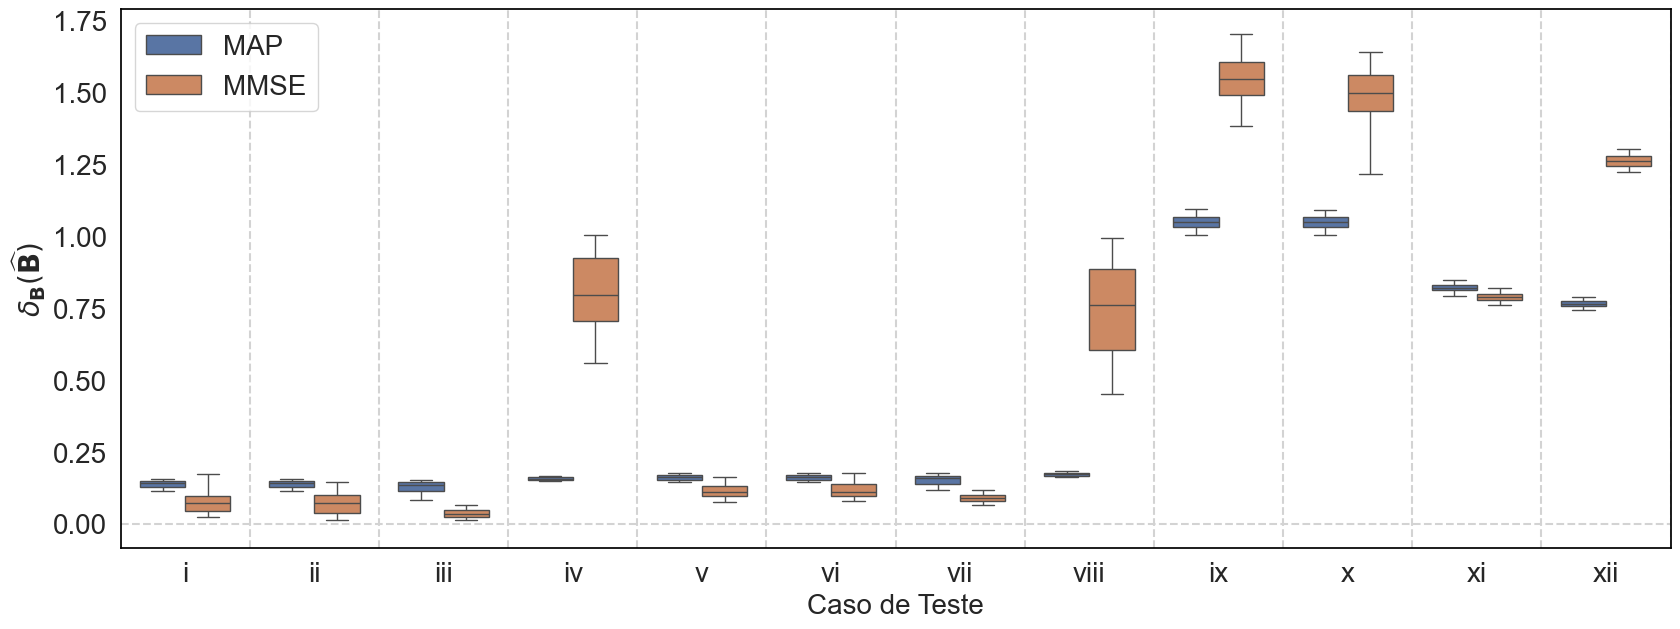

In [19]:
lrt.plot_errors_boxplot_map_mmse(
    yranges = None,
    whis_lims=(5,95),
    box_color='gray',
    box_linecolor='black',
    box_linewidth=.5,
    save_dir=analysis_dir,
    label_size=20,
    legend_size=20,
)